The following code  implements a residual-based sampling online outlier-robust PCA algorithm.

The results can be reproduced using Python 3.7, and no extra packages are needed.

The deatils of the code are as follows:

   Parameters
   
    M : np.ndarray
        Data matrix of shape (d, n) whose columns arrive one by one.
    xi : float
        Parameter used in the error bound (initial arbitrary value).
    z : int or float
        Upper bound (budget) on the number of outlier columns provided.
    k : float or int
        Parameter for scaling (must be > 1).
    inlier : np.ndarray, optional
        Inlier data; if None then inlier = M.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    outlier_count : int
         Total number of columns flagged as outliers.
    V_final : np.ndarray
         Final subspace basis matrix (each column is a learned unit basis vector).
    embedding_dimension : int
         The number of basis vectors learned (i.e., the output embedding dimension).
    provided_outlier_count : int
         The number of outlier columns provided (input parameter z).
  

In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt

In [11]:
import numpy as np
import copy

def ORPCA_Reimp(M, xi, z, k, inlier=None, seed=None):

    if seed is not None:
        np.random.seed(seed)
    if inlier is None:
        inlier = M

    d, n = M.shape
    size = M.shape

    # --- Inlined d_tau logic ---
    # Compute mu based on inlier data.
    mu = np.prod(size) / (4.0 * np.sum(np.abs(inlier)))
    # Compute SVD on inlier data.
    u, s, vh = np.linalg.svd(inlier, full_matrices=False)
    tau = 1.0 / mu
    # Keep singular values greater than tau.
    idx = s > tau
    s_new = s[idx] - tau
    r_val = np.sum(idx)
    if r_val > 0:
        L = (u[:, :r_val] * s_new) @ vh[:r_val, :]
    else:
        L = inlier.copy()
    # --- End inlined d_tau logic ---

    # Additional parameter.
    lamb_val = 1.0 / np.sqrt(np.max(size))

    # Compute fixed output embedding dimension:
    # r = 2k log(||A_in||_F^2 / xi)
    r_dim = int(np.ceil(2 * k * np.log((np.linalg.norm(inlier, 'fro')**2) / xi)))

    # Initialize algorithm parameters.
    current_rank = 0    # Number of new basis vectors added (output embedding dimension)
    alpha = 0.0         # Running accumulator for inlier updates.
    beta = 0.0          # Running accumulator for outlier updates.
    outlier_count = 0   # Count of columns flagged as outliers.

    # Basis vectors accumulated in V_list.
    V_list = []

    # Initialize accumulators as column vectors.
    w = np.zeros((d, 1))
    t_acc = np.zeros((d, 1))

    # U is the projection matrix onto the current subspace.
    U = np.zeros((d, d))

    # Constant for scaling (C) and use xi in the denominator.
    C = 1

    denom = 512 * xi

    errors = []

    for i in range(n):
        # Extract the i-th column as (d x 1).
        ai = M[:, i:i+1]

        # Compute the residual of ai w.r.t. current projection.
        r = ai - U @ ai
        norm_r = np.linalg.norm(r)

        # Compute the sampling probability:
        # p_Ai = k * ||Π⊥_V A_i||^2 / (512 ξ)
        p_Ai = (k * (norm_r**2)) / denom

        # --- Inlier update branch ---
        if p_Ai < (k / z):
            alpha += p_Ai
            X_sign = 2 * np.random.randint(2) - 1
            w = w + X_sign * ai
            if alpha >= 1:
                temp_w = w - U @ w
                norm_temp = np.linalg.norm(temp_w)
                if norm_temp > 0:
                    temp_w = temp_w / norm_temp
                    V_list.append(temp_w.flatten())
                    U = U + temp_w @ temp_w.T
                    current_rank += 1
                # Reset accumulators.
                w = np.zeros((d, 1))
                alpha = 0.0
                t_acc = np.zeros((d, 1))
                beta = 0.0
        else:
            # Mark ai as an outlier.
            outlier_count += 1
            # --- Non-special outlier branch ---
            if p_Ai < 1:
                decisions = [-1, 1]
                dist = [1 - p_Ai, p_Ai]
                dec = np.random.choice(decisions, 1, p=dist)[0]
                if dec == 1:
                    beta += k / z
                    X_sign = 2 * np.random.randint(2) - 1
                    t_acc = t_acc + (X_sign / np.sqrt(p_Ai)) * ai
                    if beta >= 1:
                        temp_t = t_acc - U @ t_acc
                        norm_temp = np.linalg.norm(temp_t)
                        if norm_temp > 0:
                            temp_t = temp_t / norm_temp
                            V_list.append(temp_t.flatten())
                            U = U + temp_t @ temp_t.T
                            current_rank += 1
                        t_acc = np.zeros((d, 1))
                        beta = 0.0
            # --- Special outlier branch ---
            elif p_Ai >= 1:
                temp_A = ai - U @ ai
                norm_temp = np.linalg.norm(temp_A)
                if norm_temp > 0:
                    temp_A = temp_A / norm_temp
                decisions = [-1, 1]
                dist = [1 - k * C / z, k * C / z]
                dec = np.random.choice(decisions, 1, p=dist)[0]
                if dec == 1:
                    V_list.append(temp_A.flatten())
                    U = U + temp_A @ temp_A.T
                    current_rank += 1
                    if t_acc.size != 0:
                        temp_t = t_acc - U @ t_acc
                        norm_temp2 = np.linalg.norm(temp_t)
                        if norm_temp2 > 0:
                            temp_t = temp_t / norm_temp2
                            V_list.append(temp_t.flatten())
                            U = U + temp_t @ temp_t.T
                            current_rank += 1
                    t_acc = np.zeros((d, 1))
                    beta = 0.0

        # Compute the embedding for the current column: y_i = V^T ai.
        if len(V_list) > 0:
            V_mat = np.column_stack(V_list)  # shape: (d, current_basis_count)
            y = V_mat.T @ ai                  # shape: (current_basis_count, 1)
        else:
            y = np.zeros((0, 1))
        # Resize y to fixed dimension r_dim by padding with zeros.
        curr_dim = y.shape[0]
        if curr_dim < r_dim:
            padding = np.zeros((r_dim - curr_dim, 1))
            y = np.vstack([y, padding])
        elif curr_dim > r_dim:
            y = y[:r_dim]
        errors.append(y.flatten())

    if len(V_list) > 0:
        V_final = np.column_stack(V_list)
    else:
        V_final = np.zeros((d, 0))

    return outlier_count, V_final, current_rank, errors, z




In [15]:
if __name__ == "__main__":
    np.random.seed(1)

    dimensionality = 500
    num_samples = 1000
    ks = [5]
    lams = [0.1, 0.15, 0.2]
    sigmas = [2]
    mag = 10
    num_all = dimensionality * num_samples

    # Reference arrays for original algorithm
    original_outlier_counts = [132, 235, 564]
    original_embedding_dims = [12, 14, 6]

    for k in ks:
        for lam_index, lam in enumerate(lams):
            for sigma in sigmas:
                np.random.seed(1)

                # Generate low-dimensional basis A_basis.
                A_basis = sigma * np.random.rand(dimensionality, k)
                # Generate coefficient matrix X.
                X = np.random.rand(k, num_samples)
                # Create inlier data.
                data_demo_inlier = A_basis @ X

                # Generate outlier data.
                num_outliers = int(num_samples * lam)
                data_demo_outlier = np.zeros((dimensionality, num_outliers))
                half = int(num_outliers / 2)
                data_demo_outlier[:, :half] = mag * sigma * np.random.rand(dimensionality, half)
                data_demo_outlier[:, half:] = -mag * sigma * np.random.rand(dimensionality, num_outliers - half)

                # Create final dataset: replace randomly chosen inlier columns with outliers.
                data_demo = copy.deepcopy(data_demo_inlier)
                indices = list(range(num_samples))
                np.random.shuffle(indices)
                for i in range(num_outliers):
                    data_demo[:, indices[i]] = data_demo_outlier[:, i]

                xi = 0.001
                z = num_outliers

                outlier_count, V_final, embed_dim, errors, provided_outliers = ORPCA_Reimp(data_demo, xi, z, k, seed=1)

                print("----------------------------------------------------")
                print("Parameters: k = {}, lambda = {}, sigma = {}".format(k, lam, sigma))
                print("Number of outliers provided: {}".format(provided_outliers))
                print("Total number of outliers encountered: {}".format(outlier_count))
                print("Original algorithm outlier count: {}".format(original_outlier_counts[lam_index]))
                print("Output embedding dimension (number of basis vectors): {}".format(embed_dim))
                print("Original algorithm output embedding dimension: {}".format(original_embedding_dims[lam_index]))
                print("----------------------------------------------------\n")

----------------------------------------------------
Parameters: k = 5, lambda = 0.1, sigma = 2
Number of outliers provided: 100
Total number of outliers encountered: 214
Original algorithm outlier count: 132
Output embedding dimension (number of basis vectors): 11
Original algorithm output embedding dimension: 12
----------------------------------------------------

----------------------------------------------------
Parameters: k = 5, lambda = 0.15, sigma = 2
Number of outliers provided: 150
Total number of outliers encountered: 294
Original algorithm outlier count: 235
Output embedding dimension (number of basis vectors): 10
Original algorithm output embedding dimension: 14
----------------------------------------------------

----------------------------------------------------
Parameters: k = 5, lambda = 0.2, sigma = 2
Number of outliers provided: 200
Total number of outliers encountered: 503
Original algorithm outlier count: 564
Output embedding dimension (number of basis vector

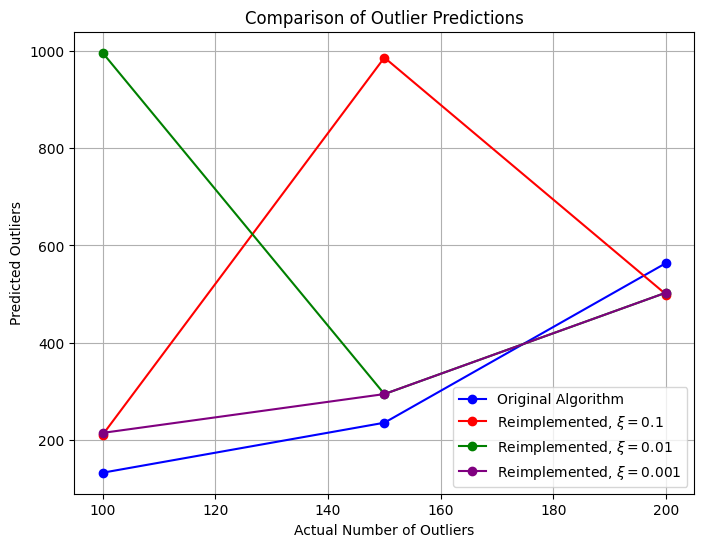

In [12]:
#Effect on xi on predicted number of outliers.
actual=[100,150,200];#actual number of outliers
Orig_alg=[132,235,564];#Ouliers predicted by original algorithm
Re_imp_xi_1=[210,987,499];#Outliers for xi=0.1
Re_imp_xi_2=[997,294,503];#Outliers for xi=0.01
Re_imp_xi_3=[214,294,503];#Outliers for xi=0.001

x = actual

plt.figure(figsize=(8, 6))
plt.plot(x, Orig_alg, marker='o', linestyle='-', color='blue', label='Original Algorithm')
plt.plot(x, Re_imp_xi_1, marker='o', linestyle='-', color='red', label=r'Reimplemented, $\xi=0.1$')
plt.plot(x, Re_imp_xi_2, marker='o', linestyle='-', color='green', label=r'Reimplemented, $\xi=0.01$')
plt.plot(x, Re_imp_xi_3, marker='o', linestyle='-', color='purple', label=r'Reimplemented, $\xi=0.001$')

plt.xlabel('Actual Number of Outliers')
plt.ylabel('Predicted Outliers')
plt.title('Comparison of Outlier Predictions')
plt.legend()
plt.grid(True)
plt.show()


In [16]:
!pip freeze > requirements.txt